# Imports

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Data Validation and Prep:

In [5]:
train = pd.read_csv("vol_dataset_train_20150102_20221230.csv")
test = pd.read_csv("vol_dataset_test_20250102_20251231.csv")
val = pd.read_csv("vol_dataset_validation_20230103_20241231.csv")

C:\Users\Diogo\AppData\Local\Temp\ipykernel_33076\3680254594.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("vol_dataset_train_20150102_20221230.csv")
C:\Users\Diogo\AppData\Local\Temp\ipykernel_33076\3680254594.py:3: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  val = pd.read_csv("vol_dataset_validation_20230103_20241231.csv")


In [6]:
#Sort all of the values by date and get only the features we need for both the V1 and the V2 models. 
train = train.sort_values(by='date')[['date','ticker', 'y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX', 'forward_vol_5d_annual_decimel_calculated']].dropna()
test = test.sort_values(by='date')[['date','ticker','y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX', 'forward_vol_5d_annual_decimel_calculated' ]].dropna()
val = val.sort_values(by='date')[['date','ticker','y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX', 'forward_vol_5d_annual_decimel_calculated' ]].dropna()

#Set the indices to the dates, and ensure that they're in DateTime format 
train = train.set_index('date')
train.index = pd.to_datetime(train.index)
test = test.set_index('date')
test.index = pd.to_datetime(test.index)
val = val.set_index('date')
val.index = pd.to_datetime(val.index)

In [7]:
#Certify the counts for each ticker
train['ticker'].value_counts()

ticker
KCE     1995
XSD     1995
XLE     1995
XTL     1995
IYZ     1995
XSW     1995
XLK     1995
XME     1995
XAR     1995
PXQ     1995
XOP     1995
XLF     1995
XLY     1995
XLU     1995
KRE     1995
KBE     1995
PNQI    1995
XLI     1995
XPH     1995
PEJ     1995
XHB     1995
XLV     1995
XTN     1995
XHS     1995
KIE     1995
XLB     1995
XLP     1995
SPY     1995
XBI     1995
XHE     1995
XES     1995
VGT     1994
XLRE    1801
FTXG    1561
XLC     1123
BEDZ     409
Name: count, dtype: int64

In [8]:
#Since XLRE, FTXG, XLC, and BEDZ don't have enough examples, we will be removing them
#as the transformer needs uniform data for all tickers in order to work properly
train = train[~train['ticker'].isin(['XLRE', 'FTXG', 'XLC', 'BEDZ'])]

In [9]:
#Double check our value counts
train['ticker'].value_counts()

ticker
KCE     1995
XSD     1995
XLE     1995
XTL     1995
IYZ     1995
XSW     1995
XLK     1995
XME     1995
XAR     1995
PXQ     1995
XOP     1995
XLF     1995
XLY     1995
XLU     1995
KRE     1995
KBE     1995
PNQI    1995
XLI     1995
XPH     1995
PEJ     1995
XHB     1995
XLV     1995
XTN     1995
XHS     1995
KIE     1995
XLB     1995
XLP     1995
SPY     1995
XBI     1995
XHE     1995
XES     1995
VGT     1994
Name: count, dtype: int64

In [10]:
#Since VGT only has one missing day, let's add that one in so we keep as much data as possible.
#The only day missing is the first day, so we'll get the known Gold, Oil, Bond and Treasury values for that day from other datasets
# Then, we'll backfill the remaining variables from VGT's first known day. 

new_VGT_row = pd.DataFrame({
    'ticker': 'VGT', 
    'y_known_at_t': np.nan,
    'trailing_vol_annual_decimel_20d_calculated': np.nan,
    'volume': np.nan,
    'NYGOLDS': train.loc['2015-01-30', 'NYGOLDS'].iloc[0],
    'OIL_WTI_S': train.loc['2015-01-30', 'OIL_WTI_S'].iloc[0],
    'US_10Y_BOND_YLD': train.loc['2015-01-30', 'US_10Y_BOND_YLD'].iloc[0],
    'US_3M_TB_YLD': train.loc['2015-01-30', 'US_3M_TB_YLD'].iloc[0],
    'VIX': train.loc['2015-01-30', 'VIX'].iloc[0],
    'forward_vol_5d_annual_decimel_calculated': np.nan
}, index=[pd.to_datetime('2015-01-30')])

train = pd.concat([new_VGT_row, train])
train = train.sort_index()

#Backfill the remaining NaN values in the new row
train[ ['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated' , 'volume', 'forward_vol_5d_annual_decimel_calculated'] ] = train.groupby('ticker')[ ['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated' , 'volume', 'forward_vol_5d_annual_decimel_calculated'] ].bfill()

In [11]:
#Double-checking how our data looks like with the new VGT row
train

,ticker,y_known_at_t,trailing_vol_annual_decimel_20d_calculated,volume,NYGOLDS,OIL_WTI_S,US_10Y_BOND_YLD,US_3M_TB_YLD,VIX,forward_vol_5d_annual_decimel_calculated
2015-01-30,VGT,0.2622,0.2063,3656598.0,1283.1,47.79,1.65,0.02,20.97,0.1167
2015-01-30,KCE,0.2096,0.2250,2009.0,1283.1,47.79,1.65,0.02,20.97,0.1612
2015-01-30,XSD,0.1886,0.2337,59744.0,1283.1,47.79,1.65,0.02,20.97,0.1564
2015-01-30,XLE,0.3424,0.3042,87696260.0,1283.1,47.79,1.65,0.02,20.97,0.3086
2015-01-30,XTL,0.0580,0.1468,9778.0,1283.1,47.79,1.65,0.02,20.97,0.2365
...,...,...,...,...,...,...,...,...,...,...
2022-12-30,XES,0.4557,0.4446,82419.0,1824.5,80.16,3.88,4.41,21.67,0.5685
2022-12-30,XHB,0.2616,0.2257,1921194.0,1824.5,80.16,3.88,4.41,21.67,0.2222
2022-12-30,XHE,0.2591,0.2255,34277.0,1824.5,80.16,3.88,4.41,21.67,0.2212
2022-12-30,XOP,0.4949,0.3993,2201778.0,1824.5,80.16,3.88,4.41,21.67,0.4856


In [12]:
#One final check of the value counts to ensure they're all at 1995
train['ticker'].value_counts()

ticker
VGT     1995
KCE     1995
XSD     1995
XLE     1995
XTL     1995
IYZ     1995
XSW     1995
XLK     1995
XME     1995
XAR     1995
PXQ     1995
XOP     1995
XLF     1995
XLY     1995
XLU     1995
KRE     1995
KBE     1995
PNQI    1995
XLI     1995
XPH     1995
PEJ     1995
XHB     1995
XLV     1995
XTN     1995
XHS     1995
KIE     1995
XLB     1995
XLP     1995
SPY     1995
XBI     1995
XHE     1995
XES     1995
Name: count, dtype: int64

In [13]:
#Get all of the features that we need
features = ['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX']

#Create copies of the dataframes
train_scale = train.copy()
val_scale = val.copy()
test_scale = test.copy()

#Use a standard scaler to set these values to a uniform range, aiding in gradient descent. 
scaler = StandardScaler()
train_scale[features] = scaler.fit_transform(train[features])
val_scale[features]   = scaler.transform(val[features])
test_scale[features]  = scaler.transform(test[features])

# Creating Datasets that will work with a Transformer:

In [14]:
#https://keras.io/api/data_loading/timeseries/
def prep_dataset_sequences(df, IsV1):
    #Since one of our features is a 20 day volatility window, setting the sequence length to 21 will allow us the transformer to memorize 21 days of data and smooth out any day-to-day volatility that isn't important
    sequence_length = 21
    batch_size = 64
    features = ['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX']
    datasets = []

    #If this is the V1 dataset, only get the 2 features we want
    if IsV1:
        features = ['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated']
   
    #Getting indices of each ticker
    tickers = df['ticker'].unique()

    #Since transformer architectures are basically taking previous rows in memory from this array, I need to sort these rows by ticker first
    #This makes sure that it's checking for which would obfuscate the time series nature of the data
    for ticker in tickers:
        index = df['ticker'] == ticker
        X = df[index][features]
        Y = df[index]['forward_vol_5d_annual_decimel_calculated']
    
        dataset = tf.keras.utils.timeseries_dataset_from_array(
            X.values,
            Y[sequence_length - 1:].values, #TODO: Explain what you're doing here
            sequence_length=sequence_length,
            sequence_stride=1,
            batch_size=batch_size,
            shuffle=False 
        )

        datasets.append(dataset)

    sorted_dataset = tf.data.Dataset.sample_from_datasets(datasets)

    #TODO: #Shuffling data in the training dataset to encourage model to learn general trends and not just chronological increases in value (Should I do this?)

    return sorted_dataset

In [15]:
#Generate train, test, and validation dataset sequences based off of previous function, for both V1 and V2 models
train_dataset_V1 = prep_dataset_sequences(train_scale, True)
test_dataset_V1 = prep_dataset_sequences(test_scale, True)
val_dataset_V1 = prep_dataset_sequences(val_scale, True)

train_dataset_V2 = prep_dataset_sequences(train_scale, False)
test_dataset_V2 = prep_dataset_sequences(test_scale, False)
val_dataset_V2 = prep_dataset_sequences(val_scale, False)

# Transformer Architecture:

In [16]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout):
    # Attention and Normalization
    x = tf.keras.layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    #Dropout layer to avoid overfitting during training
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

    #Generate Residual Connection (Merge attention and original input matricies) to ensure that our gradients don't become extremely small or large
    x = tf.keras.layers.Add()([x, inputs])

    #Increase dimensionality to find non-linear patterns, then reduce them back to the original shape. 
    x = tf.keras.layers.Dense(units=ff_dim, # output dimension
      activation="relu")(x)
    x = tf.keras.layers.Dense(units = inputs.shape[-1])(x)

    #Dropout layer to avoid overfitting during training
    x = tf.keras.layers.Dropout(dropout)(x)

    #Another Residual Connection Layer following by Normalization to ensure our gradients don't get reduced to zero. 
    x = tf.keras.layers.Add()([x, inputs])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)    

    return x

In [17]:
def build_model(input_shape, head_size, num_heads, ff_dim, dropout, num_blocks, learning_rate):

    #Generate input
    inputs = tf.keras.layers.Input(shape= input_shape, name='Input')

    x = inputs

    #Pass inputs through transformer blocks
    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    #Flatten the predictions into a 1 dimensional array
    x = tf.keras.layers.Flatten()(x)

    #One more droupout layer to avoid overfitting during training
    x = tf.keras.layers.Dropout(dropout)(x)

    #Spit out a single value of prediction
    outputs = tf.keras.layers.Dense(1, name="Output")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    #Compile the model
    model.compile(loss = 'mse',
             optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
             metrics = ['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse'), tf.keras.metrics.R2Score(name='r_squared')])

    return model
    

In [36]:
#Early Stopping callback, essential as we need to run this slow transformer for several Epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='val_loss', 
verbose=1,
patience=15,
mode='min',
restore_best_weights=True)

# Building, Compiling, and Running Models:

In [29]:
#Build the model V1 with only our two features, over a 21 day sequence length, with 4 attention heads, increasing dimensionality 
# by 256 when passing through feedforward layer. Droput 10% of weights randomly and have 4 transformer encoder blocks
model_V1 = build_model( (21,2) , 21, 2, 256, 0.1,2, 1e-3)

# Fit the model.
history_V1 = model_V1.fit(
  train_dataset_V1,          # corresponding binary labels
  epochs=100,             # number of passes through the training data
  validation_data=val_dataset_V1, # use a fraction of the examples for validation
  verbose=1,             # display some progress output during training
  callbacks = [early_stopping]
  )

model_V1.summary()

Epoch 1/200
    992/Unknown 18s 14ms/step - loss: 0.6978 - mae: 0.5749 - r_squared: -51.2618 - rmse: 0.7947

C:\Users\Diogo\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


992/992 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.2909 - mae: 0.3528 - r_squared: -9.3922 - rmse: 0.5393 - val_loss: 0.0236 - val_mae: 0.1368 - val_r_squared: -1.4691 - val_rmse: 0.1535
Epoch 2/200
992/992 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - loss: 0.0408 - mae: 0.1444 - r_squared: -0.4560 - rmse: 0.2019 - val_loss: 0.0221 - val_mae: 0.1319 - val_r_squared: -1.3174 - val_rmse: 0.1487
Epoch 3/200
992/992 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.0294 - mae: 0.1159 - r_squared: -0.0516 - rmse: 0.1716 - val_loss: 0.0230 - val_mae: 0.1348 - val_r_squared: -1.4075 - val_rmse: 0.1516
Epoch 4/200
992/992 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 0.0273 - mae: 0.1088 - r_squared: 0.0256 - rmse: 0.1651 - val_loss: 0.0238 - val_mae: 0.1375 - val_r_squared: -1.4916 - val_rmse: 0.1542
Epoch 5/200
992/992 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - loss: 0.0266 - mae: 0.1066 - r_squared: 0.0490 - rmse: 0.1631 - val_loss: 0.0236 - val_mae: 0.1368 - val_r_squared: -1.4685 - val_rmse: 0.1535
Epoch 6/2

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 21, 2)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 21, 2)     │        464 │ Input[0][0],      │
│ (MultiHeadAttentio… │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_56          │ (None, 21, 2)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 2)     │          4 │ dropout_56[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_34 (Add)        │ (None, 21, 2)     │          0 │ layer_normalizat… │
│                     │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 21, 256)   │        768 │ add_34[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 21, 2)     │        514 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_57          │ (None, 21, 2)     │          0 │ dense_35[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_35 (Add)        │ (None, 21, 2)     │          0 │ dropout_57[0][0], │
│                     │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 2)     │          4 │ add_35[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 21, 2)     │        464 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_59          │ (None, 21, 2)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 2)     │          4 │ dropout_59[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 21, 2)     │          0 │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 21, 256)   │        768 │ add_36[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 21, 2)     │        514 │ dense_36[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_60          │ (None, 21, 2)     │          0 │ dense_37[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_37 (Add)        │ (None, 21, 2)     │          0 │ dropout_60[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,655 (41.62 KB)

 Trainable params: 3,551 (13.87 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,104 (27.75 KB)

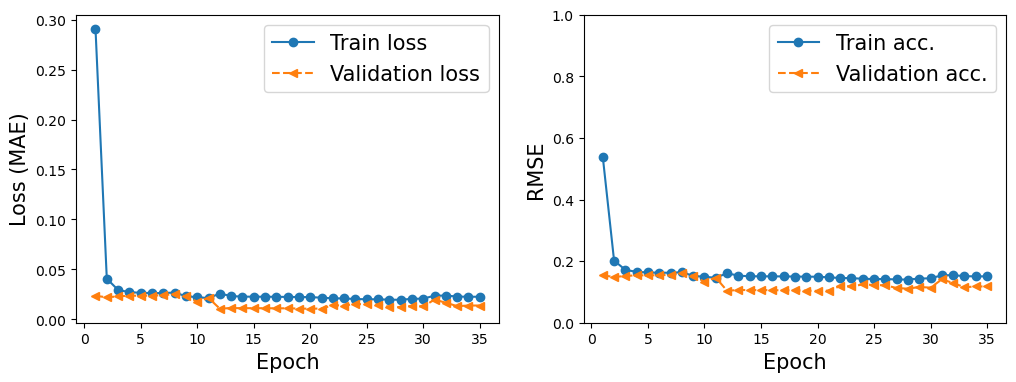

In [46]:
hist = history_V1.history
x_arr = np.arange(len(hist['loss'])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss (MAE)', size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['rmse'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_rmse'], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('RMSE', size=15)
ax.set_ylim(0,1)
plt.show()

In [30]:
# Evaluate the model on the test set
test_results_v1 = model_V1.evaluate(test_dataset_V1, verbose=1)

144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0248 - mae: 0.1103 - r_squared: -0.0511 - rmse: 0.1575


C:\Users\Diogo\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [37]:
#Build the model
model_V2 = build_model( (21,8) , 21, 2, 256, 0.1, 3 , 1e-3)

# Fit the model.
history_V2 = model_V2.fit(
  train_dataset_V2,          # corresponding binary labels
  epochs=100,             # number of passes through the training data
  validation_data=val_dataset_V2, # use a fraction of the examples for validation
  verbose=1,             # display some progress output during training
  callbacks = [early_stopping]
  )

model_V2.summary()

Epoch 1/200
    991/Unknown 34s 30ms/step - loss: 0.1426 - mae: 0.2691 - r_squared: -10.2310 - rmse: 0.3617

C:\Users\Diogo\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


992/992 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - loss: 0.0711 - mae: 0.1880 - r_squared: -1.5415 - rmse: 0.2667 - val_loss: 0.0098 - val_mae: 0.0804 - val_r_squared: -0.0285 - val_rmse: 0.0991
Epoch 2/200
992/992 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - loss: 0.0173 - mae: 0.0932 - r_squared: 0.3834 - rmse: 0.1314 - val_loss: 0.0090 - val_mae: 0.0756 - val_r_squared: 0.0579 - val_rmse: 0.0948
Epoch 3/200
992/992 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - loss: 0.0144 - mae: 0.0839 - r_squared: 0.4844 - rmse: 0.1201 - val_loss: 0.0078 - val_mae: 0.0677 - val_r_squared: 0.1783 - val_rmse: 0.0886
Epoch 4/200
992/992 ━━━━━━━━━━━━━━━━━━━━ 59s 59ms/step - loss: 0.0131 - mae: 0.0799 - r_squared: 0.5329 - rmse: 0.1143 - val_loss: 0.0077 - val_mae: 0.0662 - val_r_squared: 0.1973 - val_rmse: 0.0875
Epoch 5/200
992/992 ━━━━━━━━━━━━━━━━━━━━ 68s 68ms/step - loss: 0.0125 - mae: 0.0781 - r_squared: 0.5533 - rmse: 0.1118 - val_loss: 0.0078 - val_mae: 0.0681 - val_r_squared: 0.1783 - val_rmse: 0.0886
Epoch 6/200
992

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 21, 8)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 21, 8)     │      1,478 │ Input[0][0],      │
│ (MultiHeadAttentio… │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_86          │ (None, 21, 8)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 8)     │         16 │ dropout_86[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_52 (Add)        │ (None, 21, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 21, 256)   │      2,304 │ add_52[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 21, 8)     │      2,056 │ dense_52[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_87          │ (None, 21, 8)     │          0 │ dense_53[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_53 (Add)        │ (None, 21, 8)     │          0 │ dropout_87[0][0], │
│                     │                   │            │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 8)     │         16 │ add_53[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 21, 8)     │      1,478 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_89          │ (None, 21, 8)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 21, 8)     │         16 │ dropout_89[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_54 (Add)        │ (None, 21, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_54 (Dense)    │ (None, 21, 256)   │      2,304 │ add_54[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_55 (Dense)    │ (None, 21, 8)     │      2,056 │ dense_54[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_90          │ (None, 21, 8)     │          0 │ dense_55[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_55 (Add)        │ (None, 21, 8)     │          0 │ dropout_90[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 53,339 (208.36 KB)

 Trainable params: 17,779 (69.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,560 (138.91 KB)

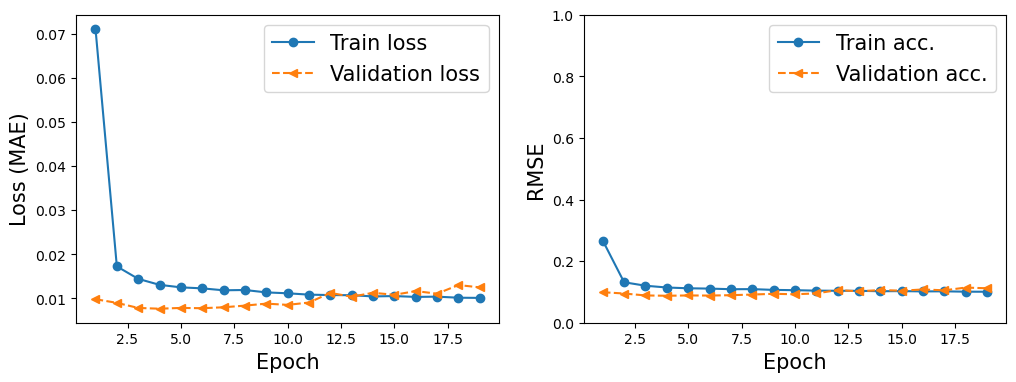

In [39]:
hist = history_V2.history
x_arr = np.arange(len(hist['loss'])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss (MAE)', size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['rmse'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_rmse'], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('RMSE', size=15)
ax.set_ylim(0,1)
plt.show()

In [38]:
# Evaluate the model on the test set
test_results = model_V2.evaluate(test_dataset_V2, verbose=1)

144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0209 - mae: 0.0852 - r_squared: 0.1143 - rmse: 0.1446


C:\Users\Diogo\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
